# Modelo Gate2: Random Forest tabular + Gate (LR) + Ensemble de Imagen

Este notebook implementa un clasificador híbrido que combina un modelo tabular y uno de imagen mediante un mecanismo de *gating*.

**Componentes del sistema:**
- **Modelo tabular (base):** un `RandomForestClassifier` entrenado sobre variables tabulares, que produce una distribución de probabilidad por clase  
  $$\mathbf{p}_{tab}(x)\in[0,1]^K,\quad \sum_{k=1}^K p_{tab,k}(x)=1$$
- **Gate (decisor):** una `LogisticRegression` entrenada para estimar la probabilidad de que el modelo tabular falle en una muestra concreta  
  $$g(x)=\mathbb{P}(\hat{y}_{tab}\neq y \mid \phi(\mathbf{p}_{tab}(x)))$$
  donde $\phi(\cdot)$ extrae medidas de incertidumbre de $\mathbf{p}_{tab}$.
- **Modelo de imagen (apoyo):** un `ImageEnsemble` que agrega predicciones de uno o varios modelos de visión (p.ej. ResNet18 / DenseNet121 / YOLO-cls) a partir de las imágenes asociadas a cada muestra, produciendo  
  $$\mathbf{p}_{img}(x)\in[0,1]^K$$

**Señales de incertidumbre usadas por el gate** (a partir de $\mathbf{p}_{tab}$):
- **Confianza:** $\max_k p_{tab,k}$
- **Margen:** $p_{(1)}-p_{(2)}$ (diferencia entre la probabilidad mayor y la segunda mayor)
- **Entropía:** $$H(\mathbf{p}_{tab})=-\sum_{k=1}^K p_{tab,k}\log p_{tab,k}$$

**Regla de decisión:** sea $\tau$ el umbral del gate (`GATE_THRESHOLD`).
- Si $g(x)<\tau$, **no se consulta imagen** y la salida final es  
  $$\mathbf{p}_{final}(x)=\mathbf{p}_{tab}(x)$$
- Si $g(x)\ge \tau$, **se consulta imagen** y se fusiona con peso $\alpha$ (`ALPHA_IMG`)  
  $$\mathbf{p}_{final}(x)=(1-\alpha)\,\mathbf{p}_{tab}(x)+\alpha\,\mathbf{p}_{img}(x)$$

**Objetivo del enfoque:** mejorar el rendimiento global y reducir errores del modelo tabular **sin** depender siempre de la imagen, usando la imagen solo cuando el gate detecta que el tabular es poco fiable.


## Install + Imports

Esta celda prepara el entorno de ejecución e importa todas las librerías necesarias para el pipeline (tabular + visión + evaluación).

**1) Instalación de dependencias**
- `!pip -q install ultralytics joblib`  
  - Instala:
    - `ultralytics`: para cargar y ejecutar modelos `YOLO` (en este notebook se usa para clasificación si se activa esa rama).
    - `joblib`: para guardar/cargar modelos de `scikit-learn` (y objetos como el `StandardScaler`) de forma eficiente.
  - La opción `-q` reduce la salida en pantalla (modo “quiet”).

**2) Utilidades generales**
- `os, random`: manejo de rutas, archivos y reproducibilidad.
- `numpy as np`: operaciones numéricas, arrays.
- `pandas as pd`: lectura y manipulación de datos tabulares (CSV).
- `tqdm.notebook.tqdm`: barras de progreso integradas en Jupyter.

**3) Bloque de Deep Learning (PyTorch)**
- `torch`, `torch.nn as nn`: base de PyTorch y definición de redes/capas.
- `torchvision.models`: arquitecturas predefinidas (p.ej. ResNet18, DenseNet121).
- `torchvision.transforms`: preprocesado de imágenes (resize, normalización, etc.).
- `PIL.Image`: lectura de imágenes desde disco.

**4) Persistencia de modelos**
- `import joblib`: serialización de modelos clásicos (RF, LR) y escaladores.

**5) Machine Learning tabular (scikit-learn)**
- `StratifiedKFold`: validación cruzada estratificada (mantiene proporción de clases).
- `StandardScaler`: estandarización de variables tabulares.
- `RandomForestClassifier`: modelo tabular base.
- `LogisticRegression`: modelo del gate (decisor).
- Métricas:
  - `accuracy_score`, `f1_score`
  - `classification_report`
  - `confusion_matrix`
  - `cohen_kappa_score` (acuerdo más allá del azar)

**6) Visualización**
- `matplotlib.pyplot as plt`: gráficas base.
- `seaborn as sns`: gráficas estadísticas (heatmaps de confusión, distribuciones, etc.).

**7) Ultralytics YOLO**
- `from ultralytics import YOLO`: interfaz para cargar y ejecutar un modelo YOLO (si se usa la parte de imagen con YOLO).

In [163]:
# =========================
# CELDA 1 - INSTALL + IMPORTS
# =========================
!pip -q install ultralytics joblib

import os, random
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

import joblib

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, cohen_kappa_score

import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

print("✅ Imports OK")


✅ Imports OK



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Config general + selección del ensemble

Esta celda centraliza la **configuración del experimento**: fija la reproducibilidad, define rutas a datos, el dispositivo de ejecución y los hiperparámetros del modelo tabular, del *gate* y de la fusión con imagen.

**Qué se define aquí (idea + implementación):**
- **Reproducibilidad:** se fija `SEED` y se aplica a `random` y `numpy` para que particiones/operaciones aleatorias sean replicables.
- **Device:** `DEVICE = "cuda"` si hay GPU; si no, `"cpu"`. Se usará sobre todo para modelos de imagen.
- **Rutas:** paths a `Train_clean.csv`, `Test_clean.csv` y carpeta raíz `IMAGES_ROOT` para resolver imágenes asociadas a cada muestra.
- **Parámetros globales:** `N_SPLITS=5` para CV (OOF) y `MAX_IMAGES_PER_ROW=5` para limitar cuántas imágenes por caso se usan en predicción.
- **Modelo tabular (RF):** número de árboles y profundidad (`RF_N_EST=400`, `RF_MAX_DEPTH=20`).
- **Gate (LogReg):** regularización y convergencia (`GATE_C`, `GATE_MAX_ITER`) y el umbral `GATE_THRESHOLD` que decide si se consulta imagen.
- **Fusión:** `ALPHA_IMG=0.2` fija el peso de imagen cuando el gate activa consulta:
  $$\mathbf{p}_{final}=(1-\alpha)\mathbf{p}_{tab}+\alpha\,\mathbf{p}_{img}$$
- **Imagen:** `IMG_SIZE=224` y listas de nombres de clases para binario/multiclase (solo para mostrar/etiquetar resultados).

**Selección de modelos de imagen (lo importante):**
- `IMG_ENSEMBLE_SPECS` es una lista de “bloques” que describen el ensemble. Cada bloque indica:
  - `kind` (arquitectura: `resnet18`, `densenet121`, `yolo_cls`)
  - `weight` (peso en el soft-voting global)
  - `paths` (checkpoints, típicamente uno por fold)
- En esta configuración solo está **activo ResNet18** con 5 checkpoints; DenseNet121 y YOLO están comentados (no se usan).



In [164]:
# =========================
# CELDA 2 - CONFIG GENERAL + SELECCIÓN DE ENSEMBLE
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# CSVs
TRAIN_CSV_PATH = "../Datos/Train_clean.csv"
TEST_CSV_PATH  = "../Datos/Test_clean.csv"

# Carpeta raíz de imágenes
IMAGES_ROOT = "../Datos/images/MULTICLASE"

# Tabular
N_SPLITS = 5
MAX_IMAGES_PER_ROW = 5

# RandomForest
RF_N_EST = 400
RF_MAX_DEPTH = 20

# Gate (LogReg)
GATE_C = 1.0
GATE_MAX_ITER = 2000
GATE_THRESHOLD = 0.5  # P(gate=1) >= umbral -> consulta imagen

# Fusión cuando gate=1
ALPHA_IMG = 0.2

# Imagen
IMG_SIZE = 224

# Nombres de clase (si son 6 o 2)
class_names_multiclass = ["ACK","BCC","MEL","NEV","SCC","SEK"]
class_names_binario    = ["Benigno","Maligno"]

# ---------------------------------------------------------
# 🔥 AQUÍ defines qué modelos de imagen quieres usar
# ---------------------------------------------------------
# Cada entrada:
# - kind: "resnet18" | "densenet121" | "yolo_cls"
# - weight: peso del soft-voting global (se normaliza solo)
# - paths: lista de checkpoints (folds) para ese tipo de modelo
IMG_ENSEMBLE_SPECS = [
    {
        "kind": "resnet18",
        "weight": 0.3,
        "paths": [
            "../DAVID/final_binario/ResNet18_Binario_5Fold_fold1.pth",
            "../DAVID/final_binario/ResNet18_Binario_5Fold_fold2.pth",
            "../DAVID/final_binario/ResNet18_Binario_5Fold_fold3.pth",
            "../DAVID/final_binario/ResNet18_Binario_5Fold_fold4.pth",
            "../DAVID/final_binario/ResNet18_Binario_5Fold_fold5.pth"
        ],
    },
    # {
    #     "kind": "densenet121",
    #     "weight": 0.4,
    #     "paths": [
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold1.pth",
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold2.pth",
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold3.pth",
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold4.pth",
    #         "../DAVID/final_binario/DenseNet121_Binario_5Fold_fold5.pth"
    #     ],
    # },
    # {
    #     "kind": "yolo_cls",
    #     "weight": 0.3,
    #     "paths": [
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_1/weights/best.pt",
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_2/weights/best.pt",
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_3/weights/best.pt",
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_4/weights/best.pt",
    #         "../DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_5/weights/best.pt"
    #     ],
    # },
]

print("✅ Config OK")


DEVICE: cpu
✅ Config OK


## Carga de datos + preparación tabular

Esta celda carga los CSV de train/test y construye la matriz tabular que se usará en el **Random Forest** (y, más adelante, para generar las señales del *gate*).

**Qué hace (idea + implementación):**
- **Carga de datos:** lee `TRAIN_CSV_PATH` y `TEST_CSV_PATH` con `pd.read_csv` y muestra tamaños.
- **Verificaciones mínimas:** comprueba que existen la etiqueta `LABEL_COL = "diagnostic_binario"` y la columna `img_id` (necesaria para enlazar con imágenes).
- **Selección de variables tabulares:** define `EXCLUDE_COLS` (IDs, rutas, etiqueta y campos no predictivos) y crea `tab_cols` como el resto de columnas.
- **Limpieza simple:** rellena `NaN` en `tab_cols` con `0` tanto en train como en test.
- **Etiquetas:** extrae `y_train` y `y_test` como enteros.
- **Número de clases y nombres:** calcula `NUM_CLASSES` a partir de `y_train` y asigna `class_names` (binario/multiclase o genérico).
- **Estandarización:** ajusta `StandardScaler` con train y transforma train/test:
  - `Xtab_train = scaler.fit_transform(...)`
  - `Xtab_test  = scaler.transform(...)`
- **Salida de control:** imprime distribución de clases en train y shapes finales de `Xtab_train` y `Xtab_test`.


In [165]:
# =========================
# CELDA 3 - CARGA DATA + TABULAR PREP
# =========================
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df  = pd.read_csv(TEST_CSV_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

LABEL_COL = "diagnostic_binario"
assert LABEL_COL in train_df.columns
assert "img_id" in train_df.columns

EXCLUDE_COLS = set(["img_id","patient_id","lesion_id","patient_lesion_id","img_path",'diagnostic', LABEL_COL])
tab_cols = [c for c in train_df.columns if c not in EXCLUDE_COLS]

train_df[tab_cols] = train_df[tab_cols].fillna(0)
test_df[tab_cols]  = test_df[tab_cols].fillna(0)

y_train = train_df[LABEL_COL].astype(int).values
y_test  = test_df[LABEL_COL].astype(int).values

NUM_CLASSES = len(np.unique(y_train))

if NUM_CLASSES == 2:
    class_names = class_names_binario
elif NUM_CLASSES == 6:
    class_names = class_names_multiclass
else:
    class_names = [f"Clase_{i}" for i in range(NUM_CLASSES)]

print("✅ NUM_CLASSES:", NUM_CLASSES)
print("✅ class_names:", class_names)
print("Distribución Train:", pd.Series(y_train).value_counts().sort_index().to_dict())

scaler = StandardScaler()
Xtab_train = scaler.fit_transform(train_df[tab_cols].values.astype(np.float32))
Xtab_test  = scaler.transform(test_df[tab_cols].values.astype(np.float32))

print("Xtab_train:", Xtab_train.shape, "| Xtab_test:", Xtab_test.shape)


Train shape: (566, 89)
Test shape : (142, 89)
✅ NUM_CLASSES: 2
✅ class_names: ['Benigno', 'Maligno']
Distribución Train: {0: 324, 1: 242}
Xtab_train: (566, 83) | Xtab_test: (142, 83)


## Indexado de imágenes + helpers

Esta celda construye un **índice rápido** para localizar imágenes en disco y define funciones auxiliares para obtener las rutas de imagen asociadas a cada muestra y medir la cobertura.

**Qué hace (idea + implementación):**
- **Parser de lista de imágenes:** `parse_img_list(s)` convierte el campo `img_id` (posiblemente una cadena con varios nombres separados por comas) en una lista de filenames y limita el número con `max_images` / `MAX_IMAGES_PER_ROW`.
- **Indexado en disco:** recorre recursivamente `IMAGES_ROOT` con `os.walk` y crea `img_index = {filename: full_path}` para extensiones de imagen comunes.
- **Resolver imágenes por fila:** `row_img_paths(df, i)` devuelve las rutas completas de las imágenes de la muestra `i` (solo las que existen en el índice).
- **Cobertura:** `coverage(df)` cuenta cuántas referencias a imágenes aparecen en `img_id` y cuántas faltan (no están en `img_index`), y luego imprime el % de cobertura para train y test.


In [166]:
# =========================
# CELDA 4 - INDEXADO DE IMÁGENES + HELPERS
# =========================
def parse_img_list(s, max_images=5):
    if pd.isna(s):
        return []
    if isinstance(s, str):
        parts = [p.strip() for p in s.split(",") if p.strip()]
        return parts[:max_images]
    return []

print("🔎 Indexando imágenes en:", IMAGES_ROOT)

img_index = {}
total = 0
for root, _, files in os.walk(IMAGES_ROOT):
    for f in files:
        if f.lower().endswith((".png",".jpg",".jpeg",".bmp",".webp")):
            total += 1
            img_index[f] = os.path.join(root, f)

print("✅ Total imágenes:", total, "| indexadas:", len(img_index))

def row_img_paths(df, i):
    fns = parse_img_list(df.loc[i, "img_id"], MAX_IMAGES_PER_ROW)
    return [img_index[fn] for fn in fns if fn in img_index]

def coverage(df):
    tot, miss = 0, 0
    for s in df["img_id"].astype(str).values:
        for fn in parse_img_list(s, MAX_IMAGES_PER_ROW):
            tot += 1
            if fn not in img_index:
                miss += 1
    return tot, miss

tr_tot, tr_miss = coverage(train_df)
te_tot, te_miss = coverage(test_df)
print(f"Train refs {tr_tot} | miss {tr_miss} | cov {(1-tr_miss/max(1,tr_tot))*100:.2f}%")
print(f"Test  refs {te_tot} | miss {te_miss} | cov {(1-te_miss/max(1,te_tot))*100:.2f}%")


🔎 Indexando imágenes en: ../Datos/images/MULTICLASE
✅ Total imágenes: 802 | indexadas: 802
Train refs 649 | miss 0 | cov 100.00%
Test  refs 153 | miss 0 | cov 100.00%


## Modelos de imagen: cargar checkpoints y predecir probabilidades (robusto a “heads”)

Esta celda implementa el módulo de **predicción por imagen** y el **ensemble** que produce $\mathbf{p}_{img}$ para una muestra.

**Qué incluye (idea + implementación):**
- **Preprocesado de imagen (`img_tf_eval`):** resize a `IMG_SIZE`, conversión a tensor y normalización tipo ImageNet (lo esperado por ResNet/DenseNet).
- **Agregación de probabilidades:**
  - `softvote_mean`: promedio de probabilidades (si no hay predicciones, devuelve uniforme).
  - `weighted_softvote`: promedio ponderado entre modelos usando pesos normalizados.
- **Constructores de arquitecturas:**
  - `build_resnet18` y `build_densenet121` crean el modelo con la última capa adaptada a `num_classes`, contemplando distintas formas de head (`Linear` vs `Sequential(Dropout, Linear)`).
- **Carga robusta de checkpoints:**
  - `_detect_head_*` infiere el “formato” del head mirando claves del `state_dict` (ej. `fc.weight` vs `fc.1.weight`).
  - `_remap_*_keys_if_needed` remapea claves cuando el checkpoint y el modelo construido no coinciden (evita errores típicos al cargar pesos).
  - `load_torch_ensemble` carga una lista de checkpoints (folds) para ResNet/DenseNet, los pone en `DEVICE` y `eval()`.
  - `load_yolo_ensemble` carga una lista de modelos YOLO si se usa esa rama.
- **Predicción por imagen:**
  - `torch_probs_single_image`: forward + `softmax` y promedio entre checkpoints.
  - `yolo_probs_single_image`: usa `ym.predict(...)` y promedia.
  - `safe_open_rgb`: abre imagen en RGB y si falla crea una imagen “dummy” para no romper el pipeline.
- **Clase `ImageEnsemble`:**
  - Recibe `specs` (qué modelos usar) y normaliza sus `weights`.
  - Carga cada bloque (ResNet/DenseNet/YOLO) con sus checkpoints.
  - `probs_for_pil`: obtiene una probabilidad por cada bloque y hace soft-voting ponderado.
  - `probs_for_paths`: obtiene probas por cada imagen de la muestra y hace promedio final (soft-vote entre imágenes).
- **Instanciación final:** `img_ens = ImageEnsemble(...)` deja listo el objeto que luego se consultará cuando el gate decida usar imagen.


In [167]:
# =========================
# CELDA 5 - MODELOS DE IMAGEN (GENERAL): load + predict probs (ROBUSTO A HEADS)
# =========================
img_tf_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def softvote_mean(probs_list, num_classes):
    if len(probs_list) == 0:
        return np.ones(num_classes, dtype=np.float32) / num_classes
    return np.mean(np.stack(probs_list, axis=0), axis=0)

def weighted_softvote(probs_list, weights, num_classes):
    if len(probs_list) == 0:
        return np.ones(num_classes, dtype=np.float32) / num_classes
    w = np.asarray(weights, dtype=np.float32)
    w = np.clip(w, 0.0, None)
    if w.sum() <= 0:
        w = np.ones_like(w)
    w = w / w.sum()
    P = np.stack(probs_list, axis=0)  # (M,C)
    return (P * w[:, None]).sum(axis=0)

# --------- Builders ---------
def build_resnet18(num_classes, head_kind="linear"):
    """
    head_kind:
      - "linear": fc = Linear
      - "seq_drop_linear": fc = Sequential(Dropout, Linear)
      - "seq_linear_drop": fc = Sequential(Linear, Dropout)  (raro, pero por completitud)
    """
    m = models.resnet18(weights=None)
    in_f = m.fc.in_features
    if head_kind == "linear":
        m.fc = nn.Linear(in_f, num_classes)
    elif head_kind == "seq_drop_linear":
        m.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_f, num_classes))
    elif head_kind == "seq_linear_drop":
        m.fc = nn.Sequential(nn.Linear(in_f, num_classes), nn.Dropout(0.5))
    else:
        raise ValueError(f"Unknown head_kind: {head_kind}")
    return m

def build_densenet121(num_classes, head_kind="linear"):
    """
    head_kind:
      - "linear": classifier = Linear
      - "seq_drop_linear": classifier = Sequential(Dropout, Linear)
    """
    m = models.densenet121(weights=None)
    in_f = m.classifier.in_features
    if head_kind == "linear":
        m.classifier = nn.Linear(in_f, num_classes)
    elif head_kind == "seq_drop_linear":
        m.classifier = nn.Sequential(nn.Dropout(0.5), nn.Linear(in_f, num_classes))
    else:
        raise ValueError(f"Unknown head_kind: {head_kind}")
    return m

def _detect_head_resnet(state):
    keys = state.keys()
    # casos típicos
    if ("fc.weight" in keys) and ("fc.bias" in keys):
        return "linear"
    if ("fc.1.weight" in keys) and ("fc.1.bias" in keys):
        return "seq_drop_linear"    # Dropout=0, Linear=1
    if ("fc.0.weight" in keys) and ("fc.0.bias" in keys):
        # puede ser linear (si se guardó como fc.0 pero realmente era Sequential con Linear en 0)
        # en la práctica suele ser Sequential(Linear, ...) o algún wrapper.
        return "seq_linear_drop"    # asumimos Linear=0
    return "linear"

def _detect_head_densenet(state):
    keys = state.keys()
    if ("classifier.weight" in keys) and ("classifier.bias" in keys):
        return "linear"
    if ("classifier.1.weight" in keys) and ("classifier.1.bias" in keys):
        return "seq_drop_linear"
    if ("classifier.0.weight" in keys) and ("classifier.0.bias" in keys):
        # análogo al caso resnet
        return "linear"  # o seq_linear_drop (no lo definimos aquí porque DenseNet no suele llevar dropout después)
    return "linear"

def _remap_resnet_fc_keys_if_needed(state, head_kind):
    """
    Si construimos seq_drop_linear pero el checkpoint trae fc.weight,
    remapea a fc.1.weight / fc.1.bias, etc.
    """
    state = dict(state)  # copia
    keys = list(state.keys())

    if head_kind == "seq_drop_linear":
        # ckpt linear -> seq_drop_linear
        if ("fc.weight" in keys) and ("fc.1.weight" not in keys):
            state["fc.1.weight"] = state.pop("fc.weight")
            state["fc.1.bias"]   = state.pop("fc.bias")
        # ckpt fc.0 -> seq_drop_linear
        if ("fc.0.weight" in keys) and ("fc.1.weight" not in keys):
            state["fc.1.weight"] = state.pop("fc.0.weight")
            state["fc.1.bias"]   = state.pop("fc.0.bias")

    elif head_kind == "linear":
        # ckpt seq_drop_linear -> linear
        if ("fc.1.weight" in keys) and ("fc.weight" not in keys):
            state["fc.weight"] = state.pop("fc.1.weight")
            state["fc.bias"]   = state.pop("fc.1.bias")
        # ckpt fc.0 -> linear
        if ("fc.0.weight" in keys) and ("fc.weight" not in keys):
            state["fc.weight"] = state.pop("fc.0.weight")
            state["fc.bias"]   = state.pop("fc.0.bias")

    elif head_kind == "seq_linear_drop":
        # queremos Linear en fc.0.*
        if ("fc.weight" in keys) and ("fc.0.weight" not in keys):
            state["fc.0.weight"] = state.pop("fc.weight")
            state["fc.0.bias"]   = state.pop("fc.bias")
        if ("fc.1.weight" in keys) and ("fc.0.weight" not in keys):
            state["fc.0.weight"] = state.pop("fc.1.weight")
            state["fc.0.bias"]   = state.pop("fc.1.bias")

    return state

def _remap_densenet_classifier_keys_if_needed(state, head_kind):
    state = dict(state)
    keys = list(state.keys())

    if head_kind == "seq_drop_linear":
        if ("classifier.weight" in keys) and ("classifier.1.weight" not in keys):
            state["classifier.1.weight"] = state.pop("classifier.weight")
            state["classifier.1.bias"]   = state.pop("classifier.bias")
        if ("classifier.0.weight" in keys) and ("classifier.1.weight" not in keys):
            state["classifier.1.weight"] = state.pop("classifier.0.weight")
            state["classifier.1.bias"]   = state.pop("classifier.0.bias")

    elif head_kind == "linear":
        if ("classifier.1.weight" in keys) and ("classifier.weight" not in keys):
            state["classifier.weight"] = state.pop("classifier.1.weight")
            state["classifier.bias"]   = state.pop("classifier.1.bias")
        if ("classifier.0.weight" in keys) and ("classifier.weight" not in keys):
            state["classifier.weight"] = state.pop("classifier.0.weight")
            state["classifier.bias"]   = state.pop("classifier.0.bias")

    return state

def load_torch_ensemble(kind, paths, num_classes):
    models_list = []
    for pth in paths:
        state = torch.load(pth, map_location="cpu")
        if isinstance(state, dict) and "state_dict" in state:
            state = state["state_dict"]  # por si guardaste un checkpoint tipo lightning

        if kind == "resnet18":
            head_kind = _detect_head_resnet(state)
            m = build_resnet18(num_classes, head_kind=head_kind)
            state2 = _remap_resnet_fc_keys_if_needed(state, head_kind)
        elif kind == "densenet121":
            head_kind = _detect_head_densenet(state)
            m = build_densenet121(num_classes, head_kind=head_kind)
            state2 = _remap_densenet_classifier_keys_if_needed(state, head_kind)
        else:
            raise ValueError(f"Unknown torch kind: {kind}")

        # Carga estricta después de remap
        m.load_state_dict(state2, strict=True)
        m.to(DEVICE).eval()
        models_list.append(m)

        print(f"✅ Loaded {kind} ckpt={os.path.basename(pth)} | head={head_kind}")

    return models_list

def load_yolo_ensemble(paths):
    return [YOLO(p) for p in paths]

@torch.no_grad()
def torch_probs_single_image(models_list, pil_img, num_classes):
    x = img_tf_eval(pil_img).unsqueeze(0).to(DEVICE)
    probs = []
    for m in models_list:
        out = m(x)
        pr = torch.softmax(out, dim=1).squeeze(0).cpu().numpy().astype(np.float32)
        probs.append(pr)
    return softvote_mean(probs, num_classes)

def yolo_probs_single_image(yolo_models, pil_img, num_classes):
    probs = []
    for ym in yolo_models:
        r = ym.predict(pil_img, imgsz=IMG_SIZE, verbose=False)
        pr = r[0].probs.data.detach().cpu().numpy().astype(np.float32)
        probs.append(pr)
    return softvote_mean(probs, num_classes)

def safe_open_rgb(path):
    try:
        return Image.open(path).convert("RGB")
    except:
        return Image.new("RGB", (IMG_SIZE, IMG_SIZE))

def normalize_model_weights(specs):
    ws = np.array([float(s.get("weight", 1.0)) for s in specs], dtype=np.float32)
    ws = np.clip(ws, 0.0, None)
    if ws.sum() <= 0:
        ws = np.ones_like(ws)
    return ws / ws.sum()

class ImageEnsemble:
    def __init__(self, specs, num_classes):
        self.num_classes = num_classes
        self.specs = [s for s in specs if len(s.get("paths", [])) > 0]
        self.weights = normalize_model_weights(self.specs)

        self.blocks = []
        for s in self.specs:
            kind = s["kind"]
            paths = s["paths"]
            if kind in ("resnet18", "densenet121"):
                mdl = load_torch_ensemble(kind, paths, num_classes)
            elif kind == "yolo_cls":
                mdl = load_yolo_ensemble(paths)
            else:
                raise ValueError(f"Unknown kind: {kind}")
            self.blocks.append((kind, mdl))

        print("✅ ImageEnsemble listo:")
        for (w, s) in zip(self.weights, self.specs):
            print(f"  - {s['kind']} | n_ckpt={len(s['paths'])} | weight={w:.3f}")

    def probs_for_pil(self, pil_img):
        per_model_probs = []
        for (kind, mdl) in self.blocks:
            if kind in ("resnet18", "densenet121"):
                pr = torch_probs_single_image(mdl, pil_img, self.num_classes)
            elif kind == "yolo_cls":
                pr = yolo_probs_single_image(mdl, pil_img, self.num_classes)
            else:
                raise ValueError(kind)
            per_model_probs.append(pr)
        return weighted_softvote(per_model_probs, self.weights, self.num_classes)

    def probs_for_paths(self, img_paths):
        probs_imgs = []
        for p in img_paths:
            im = safe_open_rgb(p)
            probs_imgs.append(self.probs_for_pil(im))
        return softvote_mean(probs_imgs, self.num_classes)

img_ens = ImageEnsemble(IMG_ENSEMBLE_SPECS, NUM_CLASSES)


✅ Loaded resnet18 ckpt=ResNet18_Binario_5Fold_fold1.pth | head=seq_linear_drop
✅ Loaded resnet18 ckpt=ResNet18_Binario_5Fold_fold2.pth | head=seq_linear_drop
✅ Loaded resnet18 ckpt=ResNet18_Binario_5Fold_fold3.pth | head=seq_linear_drop
✅ Loaded resnet18 ckpt=ResNet18_Binario_5Fold_fold4.pth | head=seq_linear_drop
✅ Loaded resnet18 ckpt=ResNet18_Binario_5Fold_fold5.pth | head=seq_linear_drop
✅ ImageEnsemble listo:
  - resnet18 | n_ckpt=5 | weight=1.000


## OOF tabular (RF) + target para el gate

Esta celda genera predicciones **out-of-fold (OOF)** del `RandomForestClassifier` sobre el train y construye la etiqueta que aprenderá el *gate*.

**Qué hace (idea + implementación):**
- **CV estratificada:** crea `StratifiedKFold` con `N_SPLITS`, mezclando y fijando `SEED` para que los folds sean reproducibles y mantengan proporciones de clase.
- **Predicciones OOF del RF:** para cada fold:
  - entrena un RF en los índices de entrenamiento (`tr_idx`)
  - predice probabilidades en validación (`va_idx`) con `predict_proba`
  - guarda en:
    - `oof_proba_tab[va_idx]` las probabilidades por clase
    - `oof_pred_tab[va_idx]` la clase top-1 (`argmax`)
- **Target del gate:** define `target_gate = 1` si el RF **se equivoca** en esa muestra OOF, y `0` si acierta:
  $$target\_{gate} = \mathbb{1}[\hat{y}_{tab}^{OOF} \neq y]$$
- **Control de calidad:** imprime métricas OOF del RF (accuracy, F1-macro) y la proporción de casos con `target_gate=1` (cuántos errores del RF hay en OOF).

La salida clave de esta celda es `oof_proba_tab` (para construir features de incertidumbre) y `target_gate` (para entrenar el gate).


In [168]:
# =========================
# CELDA 6 - OOF TABULAR (RF) + TARGET PARA GATE
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba_tab = np.zeros((len(train_df), NUM_CLASSES), dtype=np.float32)
oof_pred_tab  = np.zeros((len(train_df),), dtype=int)

print("🚀 Generando OOF del RF...")

for fold, (tr_idx, va_idx) in enumerate(skf.split(Xtab_train, y_train), start=1):
    print(f"\nFOLD {fold}/{N_SPLITS}")

    rf = RandomForestClassifier(
        n_estimators=RF_N_EST,
        max_depth=RF_MAX_DEPTH,
        random_state=SEED,
        n_jobs=-1
    )
    rf.fit(Xtab_train[tr_idx], y_train[tr_idx])

    proba = rf.predict_proba(Xtab_train[va_idx])
    pred  = np.argmax(proba, axis=1)

    oof_proba_tab[va_idx] = proba
    oof_pred_tab[va_idx]  = pred

# Gate target: 1 si RF falla
target_gate = (oof_pred_tab != y_train).astype(int)

print("\n✅ OOF listo.")
print("OOF RF Accuracy:", accuracy_score(y_train, oof_pred_tab))
print("OOF RF F1-macro:", f1_score(y_train, oof_pred_tab, average="macro"))
print("Gate target (1=RF falla) ratio:", target_gate.mean())


🚀 Generando OOF del RF...

FOLD 1/5

FOLD 2/5

FOLD 3/5

FOLD 4/5

FOLD 5/5

✅ OOF listo.
OOF RF Accuracy: 0.8586572438162544
OOF RF F1-macro: 0.857358870967742
Gate target (1=RF falla) ratio: 0.1413427561837456


## Features para el gate (incertidumbre del tabular)

Esta celda transforma las probabilidades OOF del RF ($\mathbf{p}_{tab}$) en 3 **features de incertidumbre** que usará el *gate* para decidir si el tabular es fiable.

**Qué hace (idea + implementación):**
- Define `entropy(p)` para medir incertidumbre:
  - recorta probabilidades con `eps` para evitar `log(0)`
  - calcula $$H(\mathbf{p})=-\sum_k p_k \log(p_k)$$
- A partir de `oof_proba_tab` calcula, por muestra:
  - **max\_prob:** máxima probabilidad (confianza del RF)
  - **margin:** diferencia entre la mayor y la segunda mayor probabilidad (separa casos claros vs dudosos)
  - **ent:** entropía (más alta = más incertidumbre)
- Apila estas tres señales en una matriz:
  - `X_gate = [max_prob, margin, ent]` con shape `(N, 3)`

Imprime el tamaño y algunas filas de ejemplo para comprobar que las features están bien construidas.


In [169]:
# =========================
# CELDA 7 - FEATURES PARA GATE (desde incertidumbre tabular)
# =========================
def entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)

p = oof_proba_tab
max_prob = p.max(axis=1)
sorted_p = np.sort(p, axis=1)
margin = sorted_p[:, -1] - sorted_p[:, -2]
ent = entropy(p)

X_gate = np.vstack([max_prob, margin, ent]).T  # (N,3)

print("✅ Gate features:", X_gate.shape)
print("Ejemplo primeras filas:\n", X_gate[:5])


✅ Gate features: (566, 3)
Ejemplo primeras filas:
 [[       0.83        0.66     0.45589]
 [      0.565        0.13     0.68467]
 [      0.545        0.09     0.68909]
 [     0.7325       0.465     0.58076]
 [      0.975        0.95     0.11691]]


## Entrenar el gate (Logistic Regression)

Esta celda entrena el **gate** como un clasificador binario que predice si el RF va a fallar en una muestra (target `target_gate`).

**Qué hace (idea + implementación):**
- Crea una `LogisticRegression` con:
  - `C=GATE_C` y `max_iter=GATE_MAX_ITER`
  - `class_weight="balanced"` para compensar que normalmente hay menos errores (menos `1`s) que aciertos (`0`s)
  - `solver="lbfgs"` y `multi_class="auto"` (aquí el gate es binario, pero el solver es compatible)
- Entrena con `gate.fit(X_gate, target_gate)` usando las 3 features de incertidumbre (`max_prob`, `margin`, `ent`).
- Evalúa de forma rápida en el mismo conjunto:
  - calcula $P(gate=1)$ con `predict_proba`
  - aplica el umbral `GATE_THRESHOLD` para obtener decisión 0/1
  - imprime:
    - proporción de veces que el gate activaría consulta (`gate_pred ratio`)
    - accuracy del gate frente a `target_gate` (medida interna orientativa).


In [170]:
# =========================
# CELDA 8 - ENTRENAR GATE (LogReg)
# =========================
gate = LogisticRegression(
    C=GATE_C,
    max_iter=GATE_MAX_ITER,
    class_weight="balanced",
    solver="lbfgs",      # multiclass OK
    multi_class="auto"
)

gate.fit(X_gate, target_gate)
print("✅ Gate entrenada (LogReg)")

gate_pred = (gate.predict_proba(X_gate)[:,1] >= GATE_THRESHOLD).astype(int)
print("Gate pred ratio:", gate_pred.mean())
print("Gate accuracy vs target:", accuracy_score(target_gate, gate_pred))


✅ Gate entrenada (LogReg)
Gate pred ratio: 0.4045936395759717
Gate accuracy vs target: 0.6872791519434629


## Entrenar RF final (tabular)

Entrena el `RandomForestClassifier` definitivo con **todo el train tabular** (`Xtab_train`, `y_train`) usando los hiperparámetros definidos (`RF_N_EST`, `RF_MAX_DEPTH`) para usarlo luego en inferencia y fusión.


In [171]:
# =========================
# CELDA 9 - ENTRENAR RF FINAL TABULAR
# =========================
rf_final = RandomForestClassifier(
    n_estimators=RF_N_EST,
    max_depth=RF_MAX_DEPTH,
    random_state=SEED,
    n_jobs=-1
)
rf_final.fit(Xtab_train, y_train)
print("✅ RF final entrenado")


✅ RF final entrenado


## Evaluación baseline tabular (RF solo)

Evalúa el rendimiento del sistema **sin gate ni imagen**, usando únicamente el `rf_final` sobre el conjunto de test.

**Qué hace (idea + implementación):**
- Obtiene probabilidades y predicción:
  - `p_tab_test = rf_final.predict_proba(Xtab_test)`
  - `pred_tab_test = argmax(p_tab_test)`
- Reporta métricas principales:
  - Accuracy, F1-macro y Kappa.
- Imprime el `classification_report` con `class_names`.
- Calcula la matriz de confusión y la visualiza con un `heatmap` para ver en qué clases se confunde el RF.


BASELINE TABULAR (RF SOLO)
Accuracy: 0.8732394366197183
F1-macro: 0.8716094032549729
Kappa   : 0.7434250150572175

Classification report:
              precision    recall  f1-score   support

     Benigno     0.9091    0.8642    0.8861        81
     Maligno     0.8308    0.8852    0.8571        61

    accuracy                         0.8732       142
   macro avg     0.8699    0.8747    0.8716       142
weighted avg     0.8754    0.8732    0.8736       142



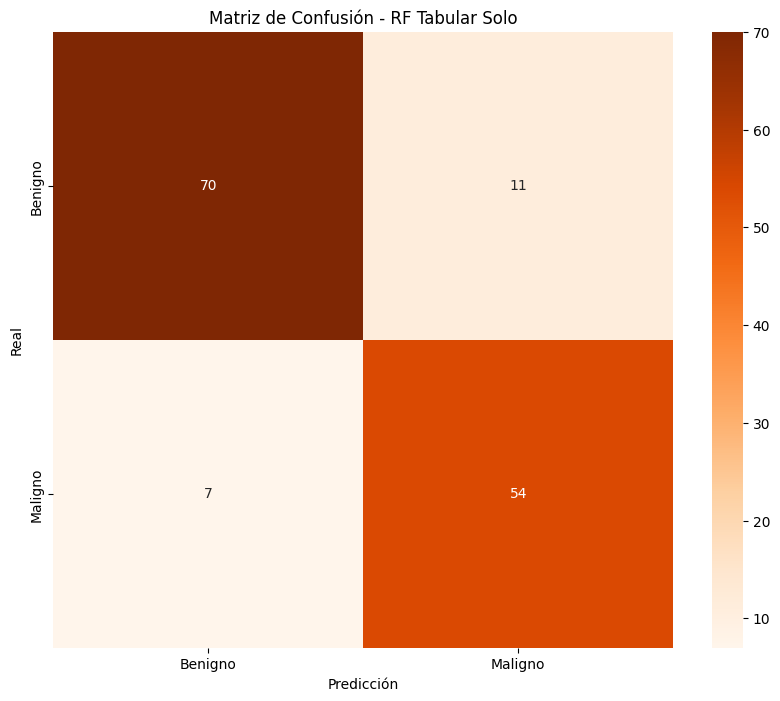

In [172]:
# =========================
# CELDA 10 - EVALUACIÓN TABULAR BASELINE (RF SOLO)
# =========================
p_tab_test = rf_final.predict_proba(Xtab_test)
pred_tab_test = np.argmax(p_tab_test, axis=1)

print("="*60)
print("BASELINE TABULAR (RF SOLO)")
print("="*60)
print("Accuracy:", accuracy_score(y_test, pred_tab_test))
print("F1-macro:", f1_score(y_test, pred_tab_test, average="macro"))
print("Kappa   :", cohen_kappa_score(y_test, pred_tab_test))

print("\nClassification report:")
labels_eval = list(range(NUM_CLASSES))
print(classification_report(y_test, pred_tab_test, labels=labels_eval, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, pred_tab_test, labels=labels_eval)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - RF Tabular Solo")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.show()


## Pipeline gated en test: $p_{img}$ + fusión con $p_{tab}$

Implementa la **inferencia completa** en test: calcula la decisión del gate por muestra, y solo si se activa consulta imagen, obtiene $p_{img}$ con el ensemble y fusiona.

**Qué hace (idea + implementación):**
- Define `gate_features_from_tab_proba(ptab)` para construir las 3 features del gate desde una fila de probabilidades tabulares: `max_prob`, `margin`, `entropy`.
- Define `fuse_probs(p_tab, p_img, alpha)` para mezclar probabilidades:
  $$p_{final}=(1-\alpha)\,p_{tab}+\alpha\,p_{img}$$
  y renormalizar por si hay problemas numéricos.
- Recorre todas las muestras de `test_df`:
  - calcula $P(gate=1)$ y decide `call = (pg >= GATE_THRESHOLD)`
  - si `call=0`: usa solo `ptab`
  - si `call=1`: obtiene rutas con `row_img_paths`, calcula `pimg = img_ens.probs_for_paths(...)` y fusiona con `ALPHA_IMG`
- Guarda `p_final_test`, calcula `pred_final_test = argmax(...)` e imprime el % de veces que se llamó a imagen (`gate_called ratio`).


In [173]:
# =========================
# CELDA 11 - PIPELINE GATED: p_img (ensemble) + fusión con p_tab
# =========================
def gate_features_from_tab_proba(p_tab_row):
    p_tab_row = np.asarray(p_tab_row, dtype=np.float32)
    mx = float(p_tab_row.max())
    sp = np.sort(p_tab_row)
    mar = float(sp[-1] - sp[-2]) if len(sp) >= 2 else 0.0
    en  = float(entropy(p_tab_row[None, :])[0])
    return np.array([mx, mar, en], dtype=np.float32)

def fuse_probs(p_tab, p_img, alpha=0.5):
    # alpha para imagen, (1-alpha) tabular
    p = alpha * p_img + (1.0 - alpha) * p_tab
    s = p.sum()
    if s <= 0:
        return np.ones_like(p) / len(p)
    return p / s

# Inferencia en TEST con gate
p_final_test = np.zeros_like(p_tab_test, dtype=np.float32)
gate_called = np.zeros((len(test_df),), dtype=int)

print("🚀 Inferencia gated en TEST...")

for i in tqdm(range(len(test_df))):
    ptab = p_tab_test[i]
    xg = gate_features_from_tab_proba(ptab)[None, :]  # (1,3)
    pg = gate.predict_proba(xg)[0,1]
    call = int(pg >= GATE_THRESHOLD)
    gate_called[i] = call

    if call == 0:
        p_final_test[i] = ptab
    else:
        paths = row_img_paths(test_df, i)
        pimg = img_ens.probs_for_paths(paths)  # (C,)
        p_final_test[i] = fuse_probs(ptab, pimg, alpha=ALPHA_IMG)

pred_final_test = np.argmax(p_final_test, axis=1)

print("✅ Done.")
print("Gate called ratio:", gate_called.mean())


🚀 Inferencia gated en TEST...


  0%|          | 0/142 [00:00<?, ?it/s]

✅ Done.
Gate called ratio: 0.3873239436619718


## Evaluación final
Evaluamos el método obteniendo el Accuracy, F1.macro y kappa, además dde un reporte específico por clase y la matriz de confusión

GATED FUSION (TAB RF + IMG ENSEMBLE)
Accuracy: 0.8873239436619719
F1-macro: 0.8858750251155314
Kappa   : 0.7719333467175266

Classification report:
              precision    recall  f1-score   support

     Benigno     0.9221    0.8765    0.8987        81
     Maligno     0.8462    0.9016    0.8730        61

    accuracy                         0.8873       142
   macro avg     0.8841    0.8891    0.8859       142
weighted avg     0.8895    0.8873    0.8877       142



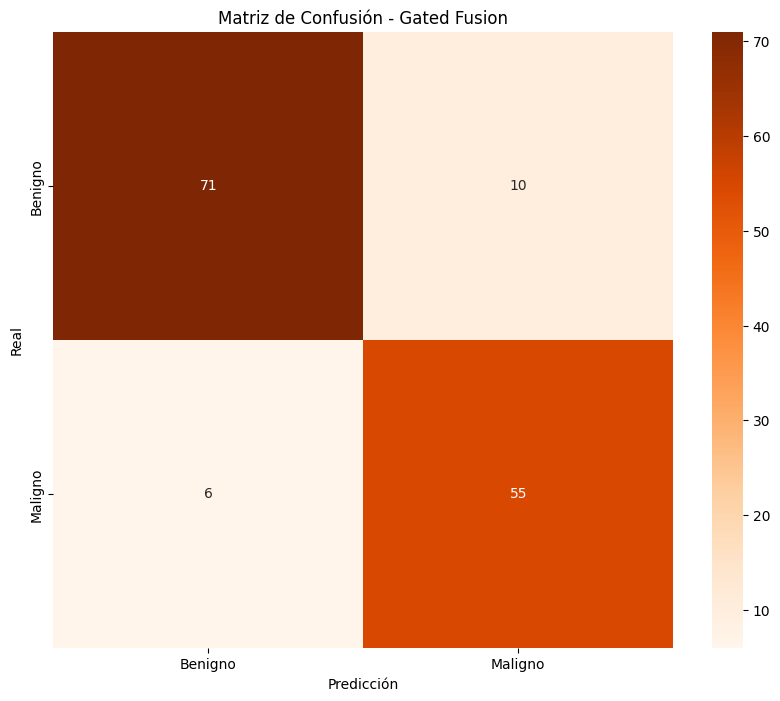

In [174]:
# =========================
# CELDA 12 - EVALUACIÓN FINAL (GATED FUSION)
# =========================
print("="*60)
print("GATED FUSION (TAB RF + IMG ENSEMBLE)")
print("="*60)
print("Accuracy:", accuracy_score(y_test, pred_final_test))
print("F1-macro:", f1_score(y_test, pred_final_test, average="macro"))
print("Kappa   :", cohen_kappa_score(y_test, pred_final_test))

print("\nClassification report:")
labels_eval = list(range(NUM_CLASSES))
print(classification_report(y_test, pred_final_test, labels=labels_eval, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, pred_final_test, labels=labels_eval)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - Gated Fusion")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.show()


## Explicabilidad + análisis del gate + impacto del ensemble

Esta celda reúne un **diagnóstico completo** del sistema (RF + Gate + ImgEnsemble) para entender *por qué* funciona y *cuándo* ayuda (o perjudica).

**Qué hace (idea + implementación):**
- **Sanity checks:** verifica que existen `gate_called`, `pred_final_test` y `p_final_test`, y reporta cuántas veces se consultó imagen.
- **Reconstruye señales del gate en test:** calcula `max_prob`, `margin`, `entropy` desde `p_tab_test` y obtiene:
  - `gate_prob_test = P(RF falla)`
  - `gate_decision` aplicando `GATE_THRESHOLD`.
- **[1] RF feature importances:** extrae `rf_final.feature_importances_`, muestra el top y lo grafica.
- **[2] Interpretación del gate:** resume estadísticos de `max_prob/margin/entropy`, compara medias entre `gate=0` y `gate=1`, y muestra coeficientes de la LogReg (qué empuja a consultar).
- **[3] Impacto del sistema:** compara métricas **RF vs SYSTEM** en:
  - todo el test
  - subset `gate=0` (sin imagen)
  - subset `gate=1` (con imagen)
  y cuantifica en `gate=1`:
  - **correcciones** (RF mal → SYSTEM bien)
  - **daños** (RF bien → SYSTEM mal)
- **[4] Impacto por clase (en gate=1):** calcula $\Delta accuracy$ por clase cuando se consulta imagen.
- **[5] Ejemplos para inspección:** lista casos “corregidos” y “dañados” con `img_id`, predicciones y `gate_prob` para revisión manual.


EXPLICABILIDAD Y ANÁLISIS DEL SISTEMA (RF + Gate + ImgEnsemble)

[0] Sanity checks
NUM_CLASSES: 2
N test: 142
Consultas ImgEnsemble: 55 (38.73%)

[1] RandomForest - Feature Importances (tabular)

Top-25 features (RF):


,feature,importance
0,biopsed_True,0.091875
1,biopsed_False,0.086881
2,age,0.067039
3,diameter_1,0.041684
4,grew_FALSE,0.040604
5,diameter_2,0.039405
6,changed_FALSE,0.029043
7,drink_Unknown,0.020836
8,gender_Unknown,0.020228
9,has_sewage_system_Unknown,0.019673


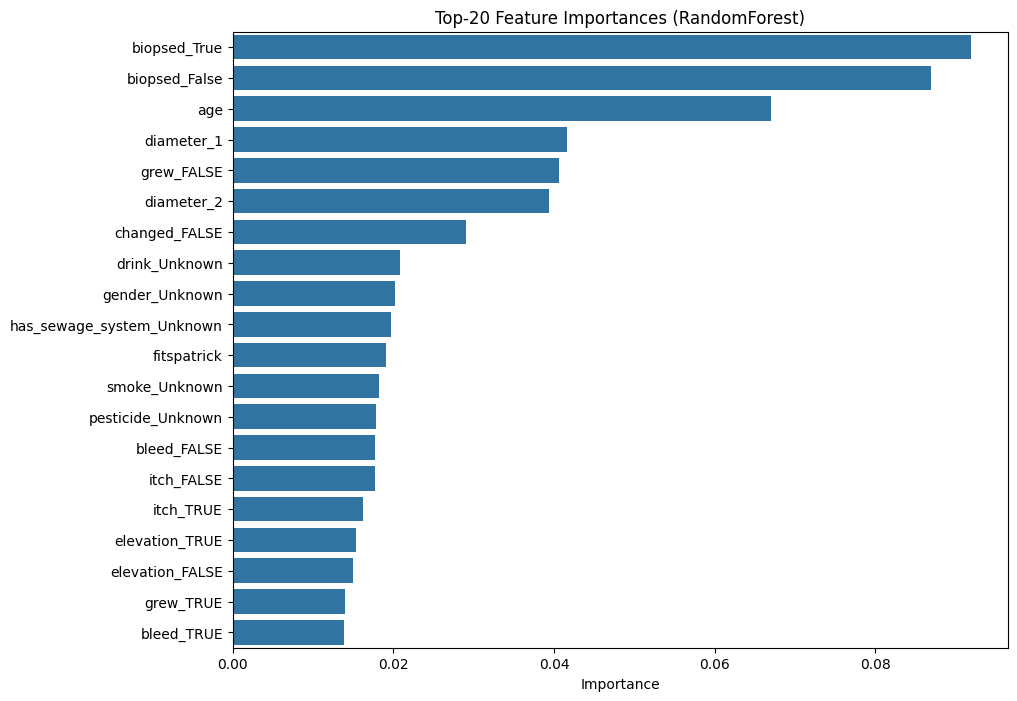

Top-5 acumulan: 32.81% de la importancia total
Top-10 acumulan: 45.73% de la importancia total
Top-20 acumulan: 62.23% de la importancia total
Top-30 acumulan: 73.89% de la importancia total
Top-50 acumulan: 90.98% de la importancia total

[2] Gate (LogReg) - Interpretación y activación

Resumen estadístico gate features:


,count,mean,std,min,25%,50%,75%,max
max_prob,142.0,0.815659,0.159094,5.125000e-01,0.681250,0.855000,0.970000,1.000000
margin,142.0,0.631318,0.318188,2.500000e-02,0.362500,0.710000,0.940000,1.000000
entropy,142.0,0.379716,0.259037,2.763102e-11,0.134435,0.413912,0.625913,0.692835
gate_prob(RF_falla),142.0,0.383982,0.271630,6.999648e-02,0.111473,0.314400,0.644762,0.824340



Media por grupo (gate=0 vs gate=1):


,max_prob,margin,entropy,gate_prob(RF_falla)
gate_decision,,,,
0,0.928727,0.857455,0.211980,0.188174
1,0.636805,0.273610,0.645042,0.693713



Coeficientes Gate LogReg (coef>0 => más prob de 'RF falla' => más consulta):


,feature,coef
2,entropy,2.779929
0,max_prob,-0.905245
1,margin,-1.810709


Intercept: 0.12920971068846318


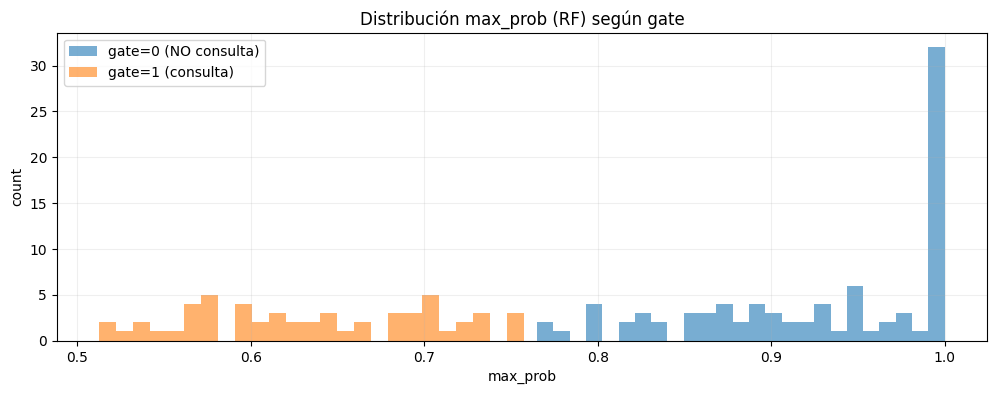

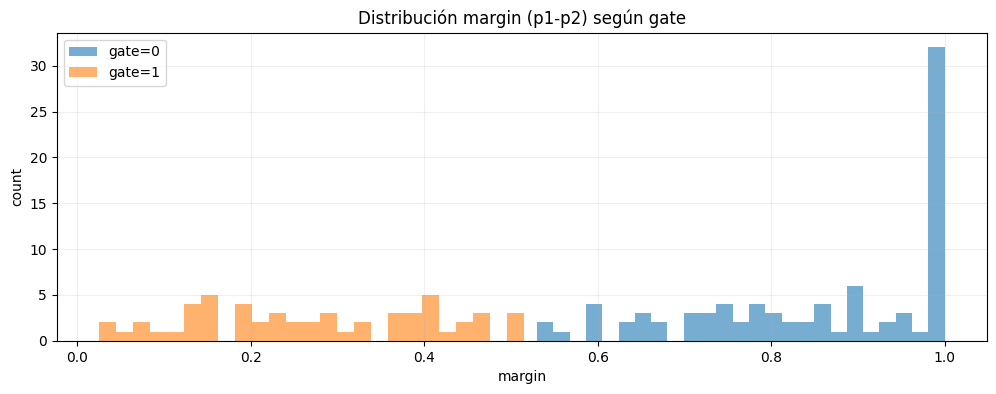

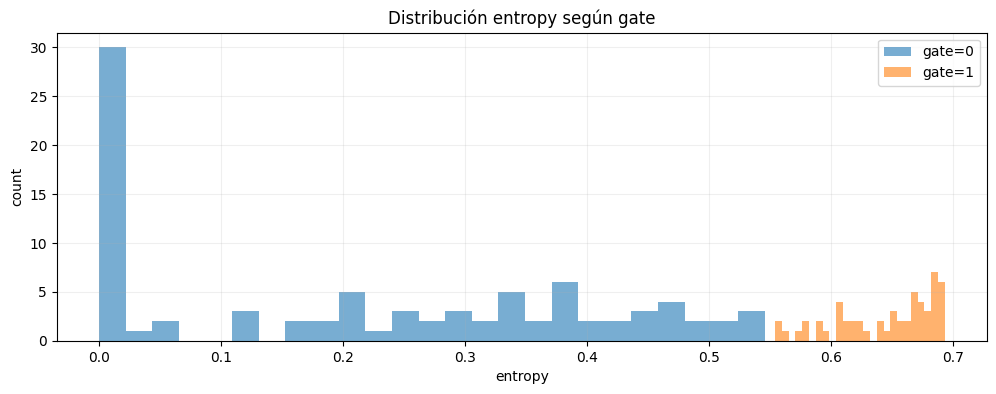


[3] Impacto de consultar ImgEnsemble: mejoras, correcciones y daños


,subset,n,acc,f1_macro
0,ALL - RF,142,0.873239,0.871609
1,ALL - SYSTEM,142,0.887324,0.885875
2,gate=0 - RF,87,0.977011,0.975284
3,gate=0 - SYSTEM,87,0.977011,0.975284
4,gate=1 - RF,55,0.709091,0.704301
5,gate=1 - SYSTEM,55,0.745455,0.741263



En subset gate=1 (consultas):
  Correcciones (RF mal -> SYSTEM bien): 5  (9.09%)
  Daños       (RF bien -> SYSTEM mal): 3    (5.45%)
  Ambos bien  : 36 (65.45%)
  Ambos mal   : 11 (20.00%)

Cambio en confianza max_prob (SYSTEM - RF):
  mean: 0.003341563256453702 | median: 0.0
  mean (gate=1): 0.008627308851712721
  mean (gate=0): -5.089395316420989e-11


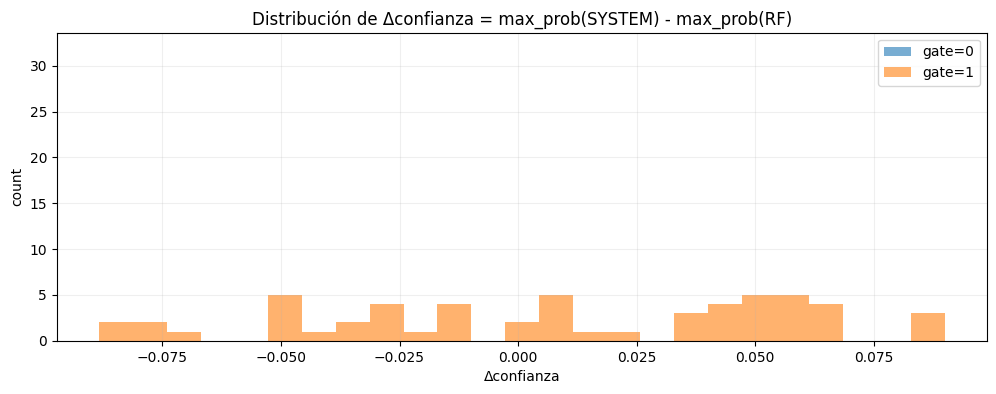


[4] Impacto por clase (en gate=1)


,class,n_gate1,acc_RF,acc_SYSTEM,delta_acc
0,Benigno,25,0.640000,0.68,0.040000
1,Maligno,30,0.766667,0.80,0.033333



[5] Ejemplos para inspección (corregidos vs dañados, gate=1)

🔧 Top corregidos (RF mal -> SYSTEM bien):


,i,img_id,y_true,RF_pred,SYS_pred,gate_prob,RF_maxprob
0,75,PAT_892_1691_881.png,Benigno,Maligno,Benigno,0.824340,0.5125
1,92,PAT_419_832_706.png,Maligno,Benigno,Maligno,0.778904,0.5700
2,96,"PAT_627_1188_755.png, PAT_627_1188_503.png",Benigno,Maligno,Benigno,0.820916,0.5175
3,99,PAT_874_1672_287.png,Maligno,Benigno,Maligno,0.769523,0.5800
4,113,PAT_897_1704_988.png,Benigno,Maligno,Benigno,0.810074,0.5325



⚠️ Top dañados (RF bien -> SYSTEM mal):


,i,img_id,y_true,RF_pred,SYS_pred,gate_prob,RF_maxprob
0,11,PAT_611_1158_156.png,Maligno,Maligno,Benigno,0.785632,0.5625
1,20,PAT_782_1493_140.png,Benigno,Benigno,Maligno,0.769523,0.5800
2,123,PAT_104_1754_276.png,Benigno,Benigno,Maligno,0.776603,0.5725



✅ Fin del análisis.


In [175]:
# =========================
# ÚLTIMA CELDA: EXPLICABILIDAD + ANÁLISIS DEL GATE + IMPACTO DEL ENSEMBLE
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

print("="*80)
print("EXPLICABILIDAD Y ANÁLISIS DEL SISTEMA (RF + Gate + ImgEnsemble)")
print("="*80)

# ---------------------------------------------------------------------
# 0) Sanity checks (variables correctas del pipeline)
# ---------------------------------------------------------------------
print("\n[0] Sanity checks")
print("NUM_CLASSES:", NUM_CLASSES)
print("N test:", len(y_test))

# En el pipeline bueno, esto se llama gate_called (0/1 por fila)
if "gate_called" in globals():
    n_calls = int(np.sum(gate_called))
    print("Consultas ImgEnsemble:", n_calls, f"({n_calls/len(y_test)*100:.2f}%)")
else:
    print("⚠️ No encuentro 'gate_called'. ¿Se llama distinto? "
          "Revisa la celda de inferencia gated.")

# Predicciones y probabilidades finales correctas
# (en tu pipeline eran pred_final_test y p_final_test)
if "pred_final_test" in globals():
    pred_sys = np.array(pred_final_test)
else:
    raise NameError("No existe 'pred_final_test'. ¿Has ejecutado la celda de inferencia gated?")

if "p_final_test" in globals():
    p_final = np.array(p_final_test)
else:
    p_final = None

# Baseline tabular (RF)
pred_rf = np.array(pred_tab_test)
p_tab = np.array(p_tab_test)
y = np.array(y_test)

# Para el gate: probabilidad de consultar (pg) no la guardabas antes.
# Si quieres análisis completo, la reconstruimos aquí:
def _entropy(p, eps=1e-12):
    p = np.clip(p, eps, 1.0)
    return -np.sum(p * np.log(p), axis=1)

max_prob = p_tab.max(axis=1)
sorted_p = np.sort(p_tab, axis=1)
margin = sorted_p[:, -1] - sorted_p[:, -2] if p_tab.shape[1] >= 2 else np.zeros(len(p_tab))
ent = _entropy(p_tab)
Xg_test = np.vstack([max_prob, margin, ent]).T  # (N,3)

gate_prob_test = gate.predict_proba(Xg_test)[:, 1]  # P(RF_falla)
gate_decision  = (gate_prob_test >= GATE_THRESHOLD).astype(int)

# ---------------------------------------------------------------------
# 1) Feature importance del RandomForest
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[1] RandomForest - Feature Importances (tabular)")
print("="*80)

if hasattr(rf_final, "feature_importances_"):
    importances = rf_final.feature_importances_
    fi_df = pd.DataFrame({"feature": tab_cols, "importance": importances})
    fi_df = fi_df.sort_values("importance", ascending=False).reset_index(drop=True)

    print("\nTop-25 features (RF):")
    display(fi_df.head(25))

    plt.figure(figsize=(10, 8))
    topn = 20
    sns.barplot(data=fi_df.head(topn), y="feature", x="importance", orient="h")
    plt.title(f"Top-{topn} Feature Importances (RandomForest)")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.show()

    fi_df["cum"] = fi_df["importance"].cumsum()
    for k in [5, 10, 20, 30, 50]:
        if k <= len(fi_df):
            print(f"Top-{k} acumulan: {fi_df.loc[k-1,'cum']*100:.2f}% de la importancia total")
else:
    print("⚠️ rf_final no tiene feature_importances_ (raro en RF).")

# ---------------------------------------------------------------------
# 2) Gate (LogReg) - interpretación
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[2] Gate (LogReg) - Interpretación y activación")
print("="*80)

gate_feat_test = pd.DataFrame({
    "max_prob": max_prob,
    "margin": margin,
    "entropy": ent,
    "gate_prob(RF_falla)": gate_prob_test,
    "gate_decision": gate_decision.astype(int)
})

print("\nResumen estadístico gate features:")
display(gate_feat_test[["max_prob","margin","entropy","gate_prob(RF_falla)"]].describe().T)

print("\nMedia por grupo (gate=0 vs gate=1):")
display(gate_feat_test.groupby("gate_decision")[["max_prob","margin","entropy","gate_prob(RF_falla)"]].mean())

if hasattr(gate, "coef_"):
    coef = gate.coef_.ravel()
    intercept = float(gate.intercept_[0])
    coef_df = pd.DataFrame({
        "feature": ["max_prob","margin","entropy"],
        "coef": coef
    }).sort_values("coef", ascending=False)
    print("\nCoeficientes Gate LogReg (coef>0 => más prob de 'RF falla' => más consulta):")
    display(coef_df)
    print("Intercept:", intercept)

# Distribuciones
plt.figure(figsize=(12,4))
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==0,"max_prob"], bins=25, alpha=0.6, label="gate=0 (NO consulta)")
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==1,"max_prob"], bins=25, alpha=0.6, label="gate=1 (consulta)")
plt.title("Distribución max_prob (RF) según gate")
plt.xlabel("max_prob"); plt.ylabel("count"); plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==0,"margin"], bins=25, alpha=0.6, label="gate=0")
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==1,"margin"], bins=25, alpha=0.6, label="gate=1")
plt.title("Distribución margin (p1-p2) según gate")
plt.xlabel("margin"); plt.ylabel("count"); plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(12,4))
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==0,"entropy"], bins=25, alpha=0.6, label="gate=0")
plt.hist(gate_feat_test.loc[gate_feat_test["gate_decision"]==1,"entropy"], bins=25, alpha=0.6, label="gate=1")
plt.title("Distribución entropy según gate")
plt.xlabel("entropy"); plt.ylabel("count"); plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

# ---------------------------------------------------------------------
# 3) Impacto del ensemble (comparación RF vs sistema)
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[3] Impacto de consultar ImgEnsemble: mejoras, correcciones y daños")
print("="*80)

idx_gate1 = np.where(gate_decision == 1)[0]
idx_gate0 = np.where(gate_decision == 0)[0]

def metrics(y_true, y_pred, name):
    return {
        "subset": name,
        "n": len(y_true),
        "acc": accuracy_score(y_true, y_pred) if len(y_true)>0 else np.nan,
        "f1_macro": f1_score(y_true, y_pred, average="macro") if len(y_true)>0 else np.nan
    }

rows = []
rows.append(metrics(y, pred_rf, "ALL - RF"))
rows.append(metrics(y, pred_sys, "ALL - SYSTEM"))

rows.append(metrics(y[idx_gate0], pred_rf[idx_gate0], "gate=0 - RF"))
rows.append(metrics(y[idx_gate0], pred_sys[idx_gate0], "gate=0 - SYSTEM"))

rows.append(metrics(y[idx_gate1], pred_rf[idx_gate1], "gate=1 - RF"))
rows.append(metrics(y[idx_gate1], pred_sys[idx_gate1], "gate=1 - SYSTEM"))

impact_df = pd.DataFrame(rows)
display(impact_df)

rf_correct_gate1  = (pred_rf[idx_gate1] == y[idx_gate1])
sys_correct_gate1 = (pred_sys[idx_gate1] == y[idx_gate1])

n_gate1 = len(idx_gate1)
corrected = np.sum((~rf_correct_gate1) & (sys_correct_gate1))
damaged   = np.sum((rf_correct_gate1) & (~sys_correct_gate1))
both_wrong = np.sum((~rf_correct_gate1) & (~sys_correct_gate1))
both_right = np.sum((rf_correct_gate1) & (sys_correct_gate1))

print("\nEn subset gate=1 (consultas):")
print(f"  Correcciones (RF mal -> SYSTEM bien): {corrected}  ({corrected/max(1,n_gate1)*100:.2f}%)")
print(f"  Daños       (RF bien -> SYSTEM mal): {damaged}    ({damaged/max(1,n_gate1)*100:.2f}%)")
print(f"  Ambos bien  : {both_right} ({both_right/max(1,n_gate1)*100:.2f}%)")
print(f"  Ambos mal   : {both_wrong} ({both_wrong/max(1,n_gate1)*100:.2f}%)")

# Cambio de confianza: max prob sistema vs RF (si hay p_final)
if p_final is not None:
    max_final = p_final.max(axis=1)
    delta_conf = max_final - max_prob
    print("\nCambio en confianza max_prob (SYSTEM - RF):")
    print("  mean:", float(delta_conf.mean()), "| median:", float(np.median(delta_conf)))
    print("  mean (gate=1):", float(delta_conf[idx_gate1].mean()) if len(idx_gate1)>0 else np.nan)
    print("  mean (gate=0):", float(delta_conf[idx_gate0].mean()) if len(idx_gate0)>0 else np.nan)

    plt.figure(figsize=(12,4))
    plt.hist(delta_conf[idx_gate0], bins=25, alpha=0.6, label="gate=0")
    plt.hist(delta_conf[idx_gate1], bins=25, alpha=0.6, label="gate=1")
    plt.title("Distribución de Δconfianza = max_prob(SYSTEM) - max_prob(RF)")
    plt.xlabel("Δconfianza"); plt.ylabel("count"); plt.legend(); plt.grid(True, alpha=0.2)
    plt.show()

# ---------------------------------------------------------------------
# 4) Impacto por clase (en gate=1)
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[4] Impacto por clase (en gate=1)")
print("="*80)

per_class_rows = []
for c in range(NUM_CLASSES):
    idx_c = idx_gate1[y[idx_gate1] == c]
    if len(idx_c) == 0:
        continue
    acc_rf  = accuracy_score(y[idx_c], pred_rf[idx_c])
    acc_sys = accuracy_score(y[idx_c], pred_sys[idx_c])
    per_class_rows.append({
        "class": class_names[c] if c < len(class_names) else str(c),
        "n_gate1": len(idx_c),
        "acc_RF": acc_rf,
        "acc_SYSTEM": acc_sys,
        "delta_acc": acc_sys - acc_rf
    })

per_class_df = pd.DataFrame(per_class_rows).sort_values("delta_acc", ascending=False)
display(per_class_df)

# ---------------------------------------------------------------------
# 5) Ejemplos "corregidos" y "dañados" (gate=1)
# ---------------------------------------------------------------------
print("\n" + "="*80)
print("[5] Ejemplos para inspección (corregidos vs dañados, gate=1)")
print("="*80)

def show_examples(kind="corrected", k=10):
    if kind == "corrected":
        mask = (~(pred_rf==y)) & ((pred_sys==y)) & (gate_decision==1)
    else:
        mask = ((pred_rf==y)) & (~(pred_sys==y)) & (gate_decision==1)

    idxs = np.where(mask)[0][:k]
    rows = []
    for i in idxs:
        rows.append({
            "i": int(i),
            "img_id": test_df.loc[i, "img_id"],
            "y_true": class_names[int(y[i])] if int(y[i]) < len(class_names) else int(y[i]),
            "RF_pred": class_names[int(pred_rf[i])] if int(pred_rf[i]) < len(class_names) else int(pred_rf[i]),
            "SYS_pred": class_names[int(pred_sys[i])] if int(pred_sys[i]) < len(class_names) else int(pred_sys[i]),
            "gate_prob": float(gate_prob_test[i]),
            "RF_maxprob": float(max_prob[i])
        })
    return pd.DataFrame(rows)

print("\n🔧 Top corregidos (RF mal -> SYSTEM bien):")
display(show_examples("corrected", k=12))

print("\n⚠️ Top dañados (RF bien -> SYSTEM mal):")
display(show_examples("damaged", k=12))

print("\n✅ Fin del análisis.")
